# MaxCal network demo

This is a simple demonstration of FLEC (what we internall call MaxCal network inference). This is mostly a conversion of `scripts/simulations/LIF2ctmc.py`.

## Loading functions

In [4]:
from maxcal_network import spk2statetime, compute_tauC, param2M, eq_constraint, objective_param, compute_min_isi,\
                                sim_Q

from statsmodels.tsa.stattools import acf

import numpy as np
from matplotlib import pyplot as plt
import itertools
from scipy.optimize import minimize
from scipy.stats import pearsonr
import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20)


np.random.seed(0)  # for reproducibility

## LIF model

We generate spikes from a 3-neuron motif.

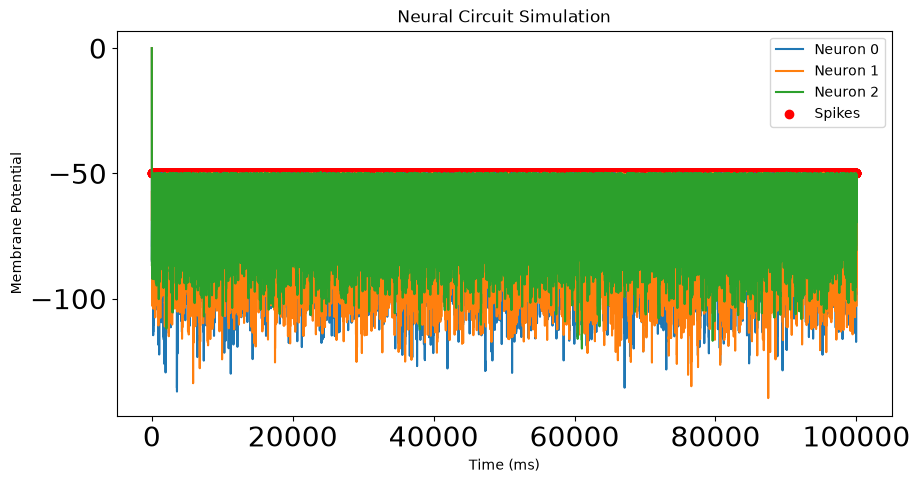

In [5]:
# Simulation parameters
N = 3
dt = 0.1  # time step in milliseconds
timesteps = 100000_0  # total simulation steps
lt = timesteps*1

# Neuron parameters
tau = 10.0  # membrane time constant
v_rest = -65.0  # resting membrane potential
v_threshold = np.array([-50, -50, -50])  # spike threshold for each neuron
v_threshold_plot = -50  # for simple visualization
v_reset = -65.0  # reset potential after a spike

# Synaptic weight matrix
alpha = 20  ### scaling the unit-weight motif
# E-I balanced circuit
synaptic_weights = np.array([[0, 1, -2],  # Neuron 0 connections
                             [1, 0, -2],  # Neuron 1 connections
                             [1, 1,  0]])*alpha  #Neuron 2 connections

### choose other motifs
# cyclic circuit
# synaptic_weights = np.array([[0, 0, 1],  # Neuron 0 connections
#                               [1, 0, 0],  # Neuron 1 connections
#                               [0, 1, 0]])*alpha  #Neuron 2 connections

# common circuit
# synaptic_weights = np.array([[0, 0, 0],  # Neuron 0 connections
#                               [1, 0, 0],  # Neuron 1 connections
#                               [1, 0, 0]])*alpha  #Neuron 2 connections

# chain circuit
# synaptic_weights = np.array([[0, 0, 0],  # Neuron 0 connections
#                               [1, 0, 0],  # Neuron 1 connections
#                               [0, 1, 0]])*alpha  # Neuron 2 connections

S = synaptic_weights*1
np.fill_diagonal(S, np.zeros(3))
noise_amp = 1.7  # 2.0 or 1.7

# Synaptic filtering parameters
tau_synaptic = 5.0  # synaptic time constant

# Initialize neuron membrane potentials and synaptic inputs
v_neurons = np.zeros((3, timesteps))
synaptic_inputs = np.zeros((3, timesteps))
spike_times = []
spike_id = []
firing = []
firing.append((np.array([]), np.array([]))) # init

# Simulation loop
for t in range(1, timesteps):

    # Update neuron membrane potentials using leaky integrate-and-fire model
    v_neurons[:, t] = v_neurons[:, t - 1] + dt/tau*(v_rest - v_neurons[:, t - 1]) + np.random.randn(3)*noise_amp
    
    # Check for spikes
    spike_indices = np.where(v_neurons[:, t] > v_threshold)[0]
    
    # Apply synaptic connections with synaptic filtering
    synaptic_inputs[:, t] = synaptic_inputs[:, t-1] + dt*( \
                            -synaptic_inputs[:, t-1]/tau_synaptic + np.sum(synaptic_weights[:, spike_indices], axis=1))
    # Update membrane potentials with synaptic inputs
    v_neurons[:, t] += synaptic_inputs[:, t]*dt
    
    # record firing
    firing.append([t+0*spike_indices, spike_indices])
    
    # reset and record spikes
    v_neurons[spike_indices, t] = v_reset  # Reset membrane potential for neurons that spiked
    if len(spike_indices) > 0:
        spike_times.append(t * dt)
        spike_id.append(spike_indices[0])

# Plotting
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.plot(np.arange(timesteps) * dt, v_neurons[i, :], label=f'Neuron {i}')

plt.scatter(spike_times, np.ones_like(spike_times) * v_threshold_plot, color='red', marker='o', label='Spikes')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential')
plt.title('Neural Circuit Simulation')
plt.legend()
plt.show()



## FLEC inference

Here we will build state-space from spike train, count the state transition flux, then infer effective coupling using these counting statistics.

### Build the state space for N neurons

In [6]:
N = 3
nc = 2**3 ### number of configurations
num_params = int((N*2**N)) 
spins = [0,1]  # binary patterns
combinations = list(itertools.product(spins, repeat=N))  # possible configurations

P0 = np.ones((nc,nc))  # uniform prior
np.fill_diagonal(P0, np.zeros(nc))
np.fill_diagonal(P0, -np.sum(P0,1))
dofs_all = nc**2 + nc
Cp_condition = np.ones(dofs_all)

### Building summary statistics

$\tau$ for occupency time and $C$ for fux

In [7]:
minisi = compute_min_isi(firing)
adapt_window = 200 #int(minisi*10)
spk_states, spk_times = spk2statetime(firing, adapt_window, lt=lt)  # embedding states
tau,C = compute_tauC(spk_states, spk_times)  # emperical measurements
tau_, C_ = tau/lt, C/lt # correct normalization
observations = np.concatenate((tau_, C_.reshape(-1))) 

### run max-cal with SLSQP optimization
constraints = ({'type': 'eq', 'fun': eq_constraint, 'args': (observations, Cp_condition)})
bounds = [(.0, 100)]*num_params

# Perform optimization using SLSQP method
param0 = np.ones(num_params)*.1 + np.random.rand(num_params)*0.0
result = minimize(objective_param, param0, args=(P0), method='SLSQP', constraints=constraints, bounds=bounds)

# computed and record the corresponding KL
param_temp = result.x
M_inf, pi_inf = param2M(param_temp)

## Generate spikes from the fitted CTMC

This is so-called the MaxCal reconstruction

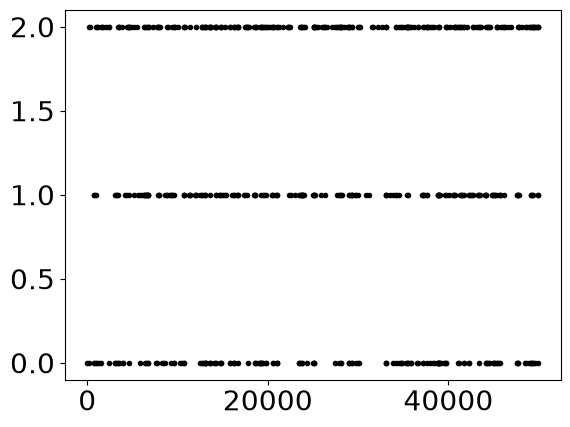

In [ ]:
M_inf = (C_/tau_[:,None]) ### direct calculation from empirical measurements

np.fill_diagonal(M_inf, np.zeros(nc))
Q = M_inf*1 
np.fill_diagonal(Q, -np.sum(Q,1))

# Q = M_data*1 
ctmc_s, ctmc_t = sim_Q(Q, 50000, 1)

# % state back to spikes
# ctmc_spkt, ctmc_spki = [],[]
plt.figure()
for tt in range(len(ctmc_t)):
    state = ctmc_s[tt]
    time = ctmc_t[tt]
    word = np.array(combinations[state])
    for nn in range(N):
        if word[nn]==1:
            plt.plot(time, nn, 'k.')



## Analyze statistics and compare to the original LIF

### Inter-spike-interval

In [17]:
###############################################################################
### Bt_LIF, LIF_sis, LIF_burst
LIF_isi = []
for nn in range(N): #(N):
    pos = np.where(np.array(spike_id)==nn)[0]
    spks = np.array(spike_times)[pos]
    if len(spks)>2:
        spks = spks[np.where(spks<lt)[0]]
        isis = np.diff(spks)/dt
        LIF_isi.append(isis)

LIF_isi = np.concatenate(LIF_isi, axis=0)

### bursts

In [18]:
Bt_LIF = []
LIF_burst = np.ones(4)

states = spk_states*1
times = spk_times*1
btt = []
for tt in range(1, len(states)):
    word = np.array(combinations[states[tt]])
    idp = int(sum(word))
    LIF_burst[idp] += 1
    btt.append(np.ones(times[tt]-times[tt-1])*idp)  # bust time series

Bt_LIF = np.concatenate((btt),axis=0)
    


### reconstruct with FLEC fitted CTMC

In [19]:
reps_ctmc = 1000        
ctmc_data, ctmc_ids = [], []
ctmc_burst = np.ones(4)
Bt_ctmc = []
for rr in range(reps_ctmc):
    ctmc_s, ctmc_t = sim_Q(Q, 10000, 1)
    ctmc_spkt, ctmc_spki = [],[]
    btt = []
    for tt in range(1, len(ctmc_t)):
        state = ctmc_s[tt]
        time = ctmc_t[tt]
        word = np.array(combinations[state])
        idp = int(sum(word))
        ctmc_burst[idp] += 1
        btt.append(np.ones(int(ctmc_t[tt]-ctmc_t[tt-1]))*idp)
        for nn in range(N):
            if word[nn]==1:
                ctmc_spkt.append(time)
                ctmc_spki.append(nn)
    ctmc_data.append(np.array(ctmc_spkt))
    ctmc_ids.append(np.array(ctmc_spki))
    
    Bt_ctmc.append(np.concatenate((btt),axis=0))



### compare these statistics

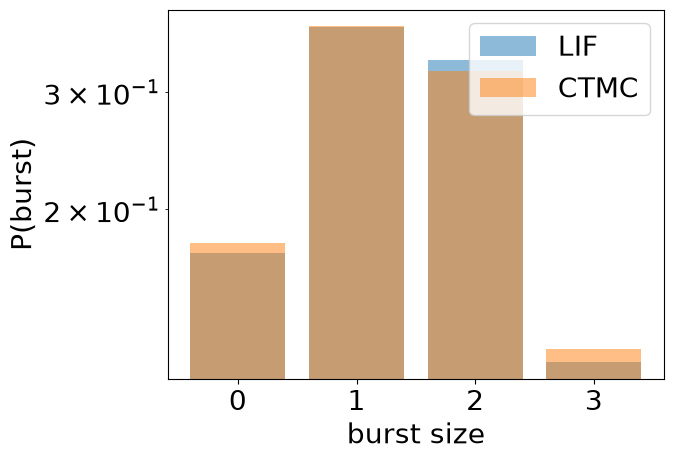

In [20]:
plt.figure()
plt.bar([0,1,2,3], LIF_burst/np.sum(LIF_burst),  alpha=0.5, label='LIF')
plt.bar([0,1,2,3], ctmc_burst/np.sum(ctmc_burst),  alpha=0.5, label='CTMC')
plt.legend(fontsize=20); plt.xlabel('burst size', fontsize=20); plt.ylabel('P(burst)', fontsize=20)
plt.yscale('log')



### compare burst-autocorrelations

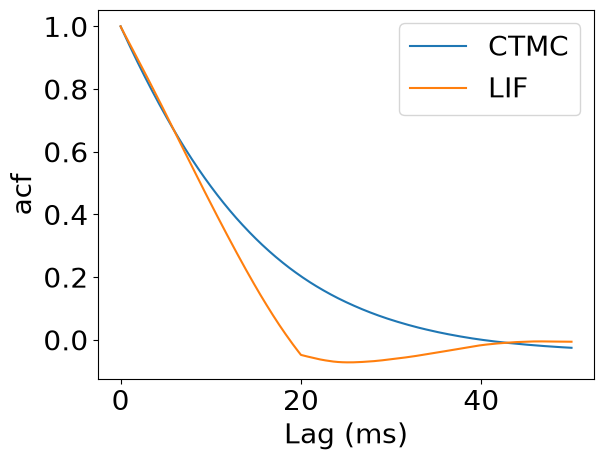

In [21]:
def compute_average_acf(time_series_list, max_lag):
    total_acf = np.zeros(max_lag + 1)
    for time_series in time_series_list:
        if len(time_series)> max_lag:
            acf_values = acf(time_series, nlags=max_lag)
            total_acf += acf_values
    average_acf = total_acf / len(time_series_list)
    return average_acf

max_lag = 500
ctmc_acf = compute_average_acf(Bt_ctmc, max_lag)
LIF_acf = compute_average_acf([Bt_LIF], max_lag)
lag = np.arange(max_lag + 1)*dt 
plt.figure()
plt.plot(lag, ctmc_acf, label='CTMC')
plt.plot(lag, LIF_acf, label='LIF')
plt.xlabel('Lag (ms)', fontsize=20); plt.ylabel('acf', fontsize=20); plt.legend(fontsize=20)



### compare ISI

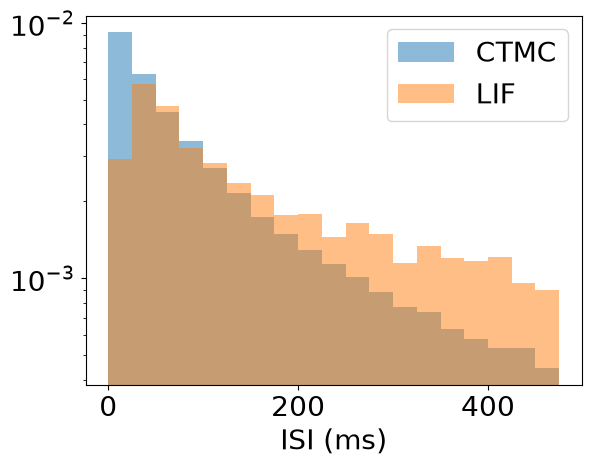

In [22]:
ctmc_isi = []
for rr in range(len(ctmc_data)):
    spkt = ctmc_data[rr]
    spki = ctmc_ids[rr]
    for nn in range(N): #(N):
        pos = np.where(spki==nn)[0]
        spks = spkt[pos]
        if len(spks)>2:
            isis = np.diff(spks)
            ctmc_isi.append(isis)

ctmc_isi = np.concatenate(ctmc_isi, axis=0)
plt.figure()
plt.hist(ctmc_isi, np.arange(0,1,.05)*500, density=True, alpha=0.5, label='CTMC')
plt.hist(LIF_isi, np.arange(0,1,.05)*500, density=True, alpha=0.5, label='LIF')
plt.legend(fontsize=20); plt.xlabel('ISI (ms)', fontsize=20)
plt.yscale('log')



### Eyeball example

Text(0.5, 1.0, 'LIF')

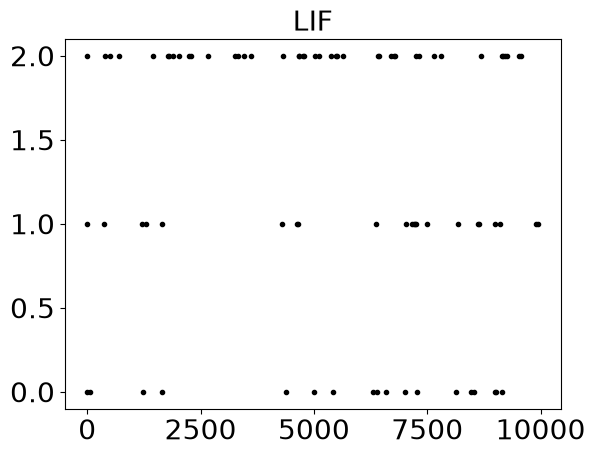

In [23]:
show_t = 10000  # 5s
plt.figure()
for tt in range(show_t-1):
    plt.plot(firing[tt][0], firing[tt][1],'k.')
plt.title('LIF', fontsize=20)

## ctmc

Text(0.5, 1.0, 'CTMC')

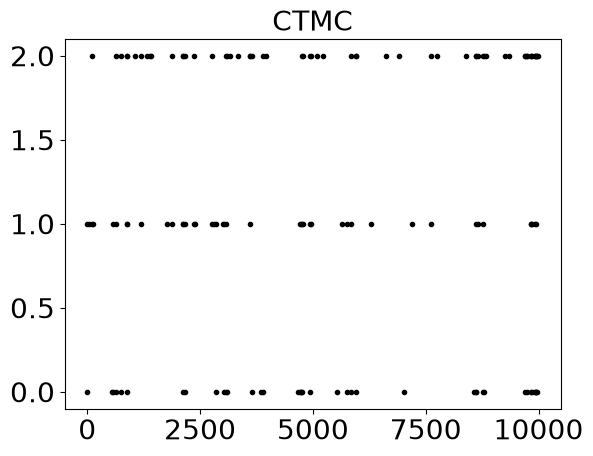

In [24]:
ctmc_s_plt, ctmc_t_plt = sim_Q(Q, show_t, 1)
plt.figure()
for tt in range(len(ctmc_t_plt)):
    state = ctmc_s_plt[tt]
    time = ctmc_t_plt[tt]
    word = np.array(combinations[state])
    for nn in range(N):
        if word[nn]==1:
            plt.plot(time, nn, 'k.')
plt.title('CTMC', fontsize=20)



## Finally, checking weight inference

Reconstruct the weights based on our hyper-cube parameterization in FLEC.

In [25]:
f1,f2,f3 = M_inf[0,4], M_inf[0,2], M_inf[0,1]
w12,w13,w21 = np.log(M_inf[4,6]/f2), np.log(M_inf[4,5]/f3), np.log(M_inf[2,6]/f1)
w23,w32,w31 = np.log(M_inf[2,3]/f3), np.log(M_inf[1,3]/f2), np.log(M_inf[1,5]/f1)
inf_w = np.array([w12,w13,w21,w23,w32,w31])

## plotting weights

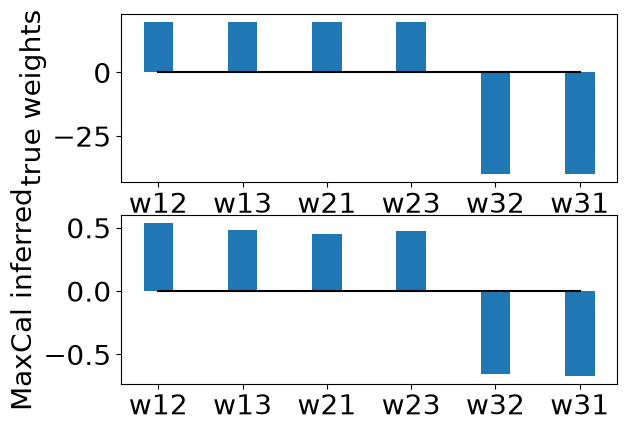

In [26]:
bar_width = 0.35
bar_positions_group2 = np.arange(6)
bar_positions_group1 = ['w12','w13','w21','w23','w32','w31']

plt.figure()
plt.subplot(211)
plt.bar(bar_positions_group1, [S[1,0],S[2,0],S[0,1],S[2,1],S[1,2],S[0,2]], width=bar_width)
plt.plot(bar_positions_group1, bar_positions_group2*0, 'k')
plt.ylabel('true weights', fontsize=20)

plt.subplot(212)
plt.bar(bar_positions_group1, np.array([w12,w13,w21,w23,w32,w31])+0, width=bar_width)
plt.plot(bar_positions_group1, bar_positions_group2*0, 'k')
plt.ylabel('MaxCal inferred', fontsize=20)

plt.show()
